In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn. preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn. cluster import DBSCAN
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datetime import datetime
import joblib
import os
import json

In [2]:
df = pd.read_csv("../../data/all_data.csv")

In [3]:
# -----------------------------------------------------------
# 1. Convert timestamps to Python datetime
# -----------------------------------------------------------
df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"], errors='coerce')
df["last_seen"] = pd.to_datetime(df["last_seen"], errors='coerce')

In [4]:
# -----------------------------------------------------------
# 2. Feature Engineering
# -----------------------------------------------------------
df["hour"] = df["timestamp_parsed"]. dt.hour
df["day"] = df["timestamp_parsed"].dt.day
df["weekday"] = df["timestamp_parsed"].dt.weekday
df["time_alive"] = (df["last_seen"] - df["timestamp_parsed"]).dt.total_seconds()

In [5]:
# -----------------------------------------------------------
# 3. Select numeric features
# -----------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number])

In [6]:
# -----------------------------------------------------------
# 4. Handle missing values
# -----------------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_cleaned = imputer.fit_transform(numeric_cols)


In [7]:
# -----------------------------------------------------------
# 5. Train/Test Split
# -----------------------------------------------------------
X_train, X_test = train_test_split(
    X_cleaned, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Train set size: (2900, 12)
Test set size: (726, 12)


In [8]:
# -----------------------------------------------------------
# 6. Scale features
# -----------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler. transform(X_test)

In [9]:
# -----------------------------------------------------------
# 7. PCA
# -----------------------------------------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca. transform(X_test_scaled)

In [10]:
# -----------------------------------------------------------
# 8. Train DBSCAN
# -----------------------------------------------------------
dbscan_model = DBSCAN(
    eps=0.7,
    min_samples=5,
    metric='euclidean'
)

In [11]:
# Fit on training data
dbscan_train_labels = dbscan_model.fit_predict(X_train_pca)

In [12]:
# Predict on test data
dbscan_test_labels = DBSCAN(eps=0.7, min_samples=5).fit_predict(X_test_pca)

print(f"\nTraining - Clusters: {len(set(dbscan_train_labels)) - (1 if -1 in dbscan_train_labels else 0)}")
print(f"Training - Noise points: {list(dbscan_train_labels).count(-1)}")
print(f"\nTest - Clusters: {len(set(dbscan_test_labels)) - (1 if -1 in dbscan_test_labels else 0)}")
print(f"Test - Noise points: {list(dbscan_test_labels).count(-1)}")


Training - Clusters: 6
Training - Noise points: 9

Test - Clusters: 3
Test - Noise points: 10


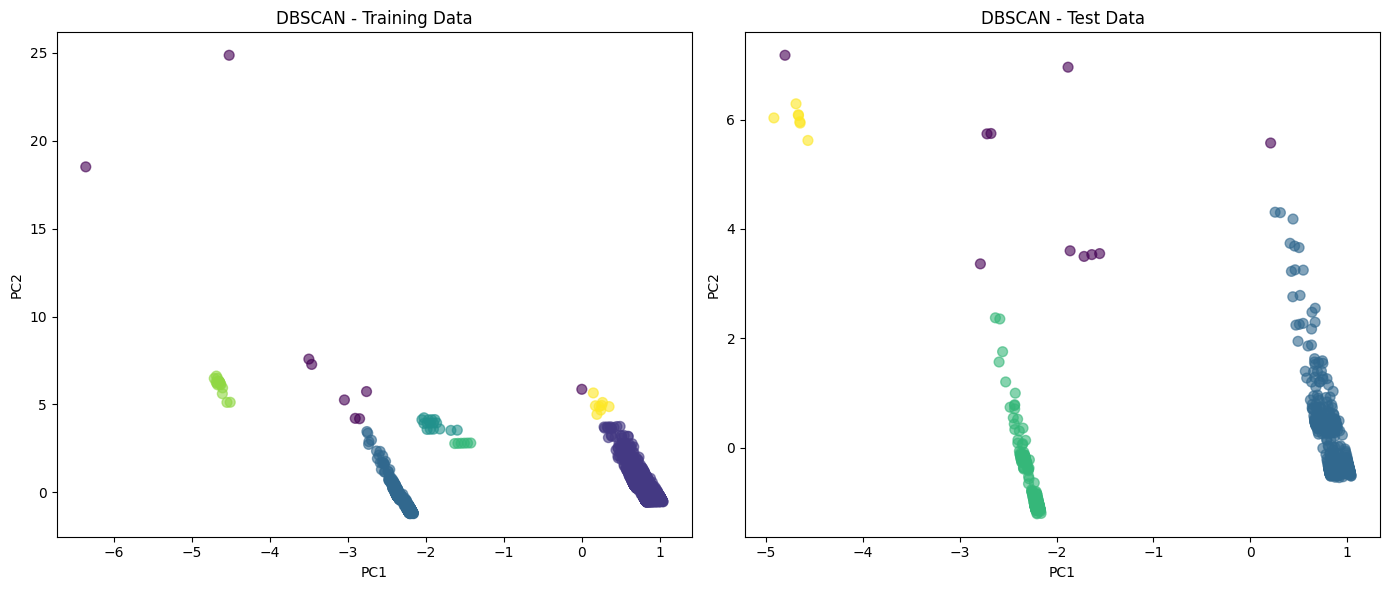

In [13]:
# -----------------------------------------------------------
# 9. Visualize
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=dbscan_train_labels, cmap='viridis', s=50, alpha=0.6)
axes[0].set_title('DBSCAN - Training Data')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_test_pca[:, 0], X_test_pca[: , 1], c=dbscan_test_labels, cmap='viridis', s=50, alpha=0.6)
axes[1].set_title('DBSCAN - Test Data')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout() 
plt.show()


In [14]:
# -----------------------------------------------------------
# 10. Save model
# -----------------------------------------------------------
os.makedirs("./builds", exist_ok=True)

joblib.dump(dbscan_model, "./builds/dbscan_model.pkl")

print("\n✅ DBSCAN model saved!")



✅ DBSCAN model saved!
